# 1. Import Libraries & Datasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1_t_results = pd.read_csv('/content/MNCAATourneyDetailedResults.csv')
df_seed = pd.read_csv('/content/MNCAATourneySeeds.csv')
df_slot = pd.read_csv('/content/MNCAATourneySlots.csv')

# 2. View and Inspect Datasets


In [ ]:
df1_t_results['Season'].value_counts()

,count
Season,
2016,67
2015,67
2013,67
2014,67
2011,67
2012,67
2024,67
2023,67
2019,67


In [ ]:
df_slot.tail(50)

,Season,Slot,StrongSeed,WeakSeed
2536,2025,R1Y2,Y02,Y15
2537,2025,R1Y3,Y03,Y14
2538,2025,R1Y4,Y04,Y13
2539,2025,R1Y5,Y05,Y12
2540,2025,R1Y6,Y06,Y11
2541,2025,R1Y7,Y07,Y10
2542,2025,R1Y8,Y08,Y09
2543,2025,R1Z1,Z01,Z16
2544,2025,R1Z2,Z02,Z15
2545,2025,R1Z3,Z03,Z14


In [ ]:
df_combined = pd.merge(df1_t_results, df_seed, how='left', left_on=('WTeamID', 'Season'), right_on=('TeamID', 'Season'))

In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 36 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Season   1449 non-null   int64 
 1   DayNum   1449 non-null   int64 
 2   WTeamID  1449 non-null   int64 
 3   WScore   1449 non-null   int64 
 4   LTeamID  1449 non-null   int64 
 5   LScore   1449 non-null   int64 
 6   WLoc     1449 non-null   object
 7   NumOT    1449 non-null   int64 
 8   WFGM     1449 non-null   int64 
 9   WFGA     1449 non-null   int64 
 10  WFGM3    1449 non-null   int64 
 11  WFGA3    1449 non-null   int64 
 12  WFTM     1449 non-null   int64 
 13  WFTA     1449 non-null   int64 
 14  WOR      1449 non-null   int64 
 15  WDR      1449 non-null   int64 
 16  WAst     1449 non-null   int64 
 17  WTO      1449 non-null   int64 
 18  WStl     1449 non-null   int64 
 19  WBlk     1449 non-null   int64 
 20  WPF      1449 non-null   int64 
 21  LFGM     1449 non-null   int64 
 22  

In [ ]:
rename_dict = {'Seed': 'w_seed',
               'TeamID': 'w_teamid'}

df_combined = df_combined.rename(columns=rename_dict)

In [ ]:
df_combined_final = pd.merge(df_combined, df_seed, how='left', left_on=('LTeamID', 'Season'), right_on=('TeamID', 'Season'))

In [ ]:
df_combined_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Season    1449 non-null   int64 
 1   DayNum    1449 non-null   int64 
 2   WTeamID   1449 non-null   int64 
 3   WScore    1449 non-null   int64 
 4   LTeamID   1449 non-null   int64 
 5   LScore    1449 non-null   int64 
 6   WLoc      1449 non-null   object
 7   NumOT     1449 non-null   int64 
 8   WFGM      1449 non-null   int64 
 9   WFGA      1449 non-null   int64 
 10  WFGM3     1449 non-null   int64 
 11  WFGA3     1449 non-null   int64 
 12  WFTM      1449 non-null   int64 
 13  WFTA      1449 non-null   int64 
 14  WOR       1449 non-null   int64 
 15  WDR       1449 non-null   int64 
 16  WAst      1449 non-null   int64 
 17  WTO       1449 non-null   int64 
 18  WStl      1449 non-null   int64 
 19  WBlk      1449 non-null   int64 
 20  WPF       1449 non-null   int64 
 21  LFGM      1449

In [ ]:
l_rename_dict = {'Seed': 'l_seed',
               'TeamID': 'l_teamid'}

df_combined_final = df_combined_final.rename(columns=l_rename_dict)

In [ ]:
df_combined_final['w_seed']


,w_seed
0,X16b
1,Z01
2,Z10
3,Z11
4,W08
...,...
1444,Y01
1445,X01
1446,Z01
1447,X01


In [ ]:
df_combined_final['w_seed_number']= df_combined_final['w_seed'].str.extract(r'(\d+)').astype(int)
df_combined_final['l_seed_number']= df_combined_final['l_seed'].str.extract(r'(\d+)').astype(int)

In [ ]:
round_mapping = {134: 0,
                 135: 0,
                 136: 1,
                 137: 1,
                 138: 2,
                 139: 2,
                 143: 3,
                 144: 3,
                 145: 4,
                 146: 4,
                 152: 5,
                 154: 6}

df_combined_final["Round"] = df_combined_final['DayNum'].map(round_mapping)

In [ ]:
df_filtered_rounds = df_combined_final[df_combined_final['Round'] != 0]

df_filtered_rounds = df_filtered_rounds[df_filtered_rounds['Season'] != 2021]

# 3. Data Exploration

Method one: Using Seed to Predict Advancment/Regular Season Record to determine winner between seed match ups. Point differential to determine same seed match ups.


## Chalk Method

In [ ]:
# Create a 'Chalk_Winner' column (the lower number is the better seed)
df_filtered_rounds['Chalk_Winner'] = df_filtered_rounds[['w_seed_number', 'l_seed_number']].min(axis=1)

# Check if the Chalk Winner matches the Actual Winner
df_filtered_rounds['Is_Correct'] = df_filtered_rounds['Chalk_Winner'] == df_filtered_rounds['w_seed_number']

chalk_accuracy_per_round = df_filtered_rounds.groupby('Round')['Is_Correct'].mean() * 100
total_chalk_accuracy = df_filtered_rounds['Is_Correct'].mean() * 100

print("Chalk Accuracy per Round (excluding Round 0) (%):\n", chalk_accuracy_per_round)
print("\nTotal Chalk Accuracy (excluding Round 0) (%):\n", total_chalk_accuracy)

Chalk Accuracy per Round (excluding Round 0) (%):
 Round
1.0    73.660714
2.0    72.619048
3.0    68.452381
4.0    52.380952
5.0    80.952381
6.0    85.714286
Name: Is_Correct, dtype: float64

Total Chalk Accuracy (excluding Round 0) (%):
 71.80650037792896


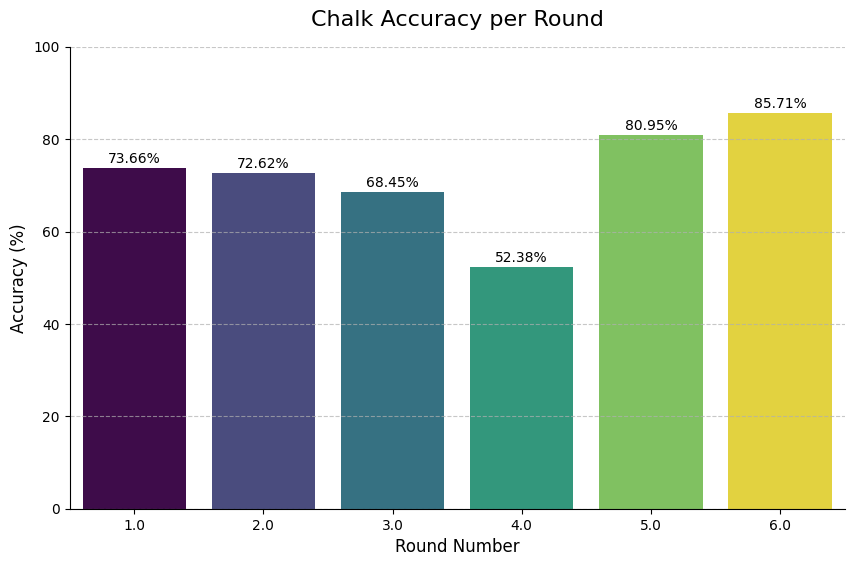

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=chalk_accuracy_per_round.index, y=chalk_accuracy_per_round.values, palette='viridis', hue=chalk_accuracy_per_round.index, legend=False)

# Add labels to the bars
for index, value in enumerate(chalk_accuracy_per_round.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', color='black', ha='center', va='bottom')

sns.despine()
plt.title('Chalk Accuracy per Round', fontsize=16, pad=15)
plt.xlabel('Round Number', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100) # Ensure y-axis starts from 0 and goes to 100%
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Calculate Expected Win Rate (Chalk Model) and Performance Difference

We define the 'expected win rate' for each seed based on a 'chalk' model. This model assumes that in any given game:
*   The team with the lower seed number (stronger seed) is expected to win against a team with a higher seed number (weaker seed).
*   If two teams have the same seed number, each is expected to win 0.5 games (a 50% chance of winning).

In [ ]:
print(len(df_filtered_rounds['Season'].value_counts()))
df_filtered_rounds['Season'].value_counts()

21


,count
Season,
2003,63
2004,63
2005,63
2006,63
2007,63
2008,63
2009,63
2010,63
2011,63


In [ ]:
# 1. Combine winners and losers so every team appearance exists
teams = pd.concat([
    df_filtered_rounds[['Season','w_teamid','w_seed_number','Round']]
        .rename(columns={'w_teamid':'teamid','w_seed_number':'seed'}),

    df_filtered_rounds[['Season','l_teamid','l_seed_number','Round']]
        .rename(columns={'l_teamid':'teamid','l_seed_number':'seed'})
])

# 2. Find the furthest round each team reached in that tournament
team_rounds = (
    teams
    .groupby(['Season','teamid','seed'])['Round']
    .max()
    .reset_index(name='round_reached')
)

# 3. Average rounds reached by seed
seed_round_performance = (
    team_rounds
    .groupby('seed')['round_reached']
    .mean()
    .reset_index(name='avg_round_reached')
)

# 4. Pretty sorted display
seed_round_performance = seed_round_performance.sort_values(
    'avg_round_reached', ascending=False
)

print(seed_round_performance.round(2))

    seed  avg_round_reached
0      1               4.11
1      2               3.26
2      3               2.98
3      4               2.60
4      5               2.15
6      7               1.96
5      6               1.83
10    11               1.74
7      8               1.69
8      9               1.65
9     10               1.55
11    12               1.50
12    13               1.23
14    15               1.12
13    14               1.11
15    16               1.02


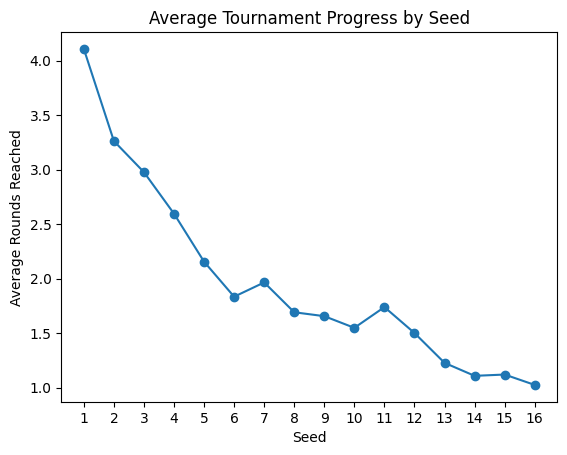

In [ ]:
import matplotlib.pyplot as plt

plot_df = seed_round_performance.sort_values('seed')

plt.figure()

plt.plot(
    plot_df['seed'],
    plot_df['avg_round_reached'],
    marker='o'
)

plt.xlabel("Seed")
plt.ylabel("Average Rounds Reached")
plt.title("Average Tournament Progress by Seed")

plt.xticks(range(1,17))

plt.show()

## Total wins by Seed

In [ ]:
seed_counts = df_filtered_rounds['w_seed_number'].value_counts().sort_index()
seed_counts



,count
w_seed_number,
1,275
2,192
3,169
4,135
5,97
6,70
7,82
8,58
9,55


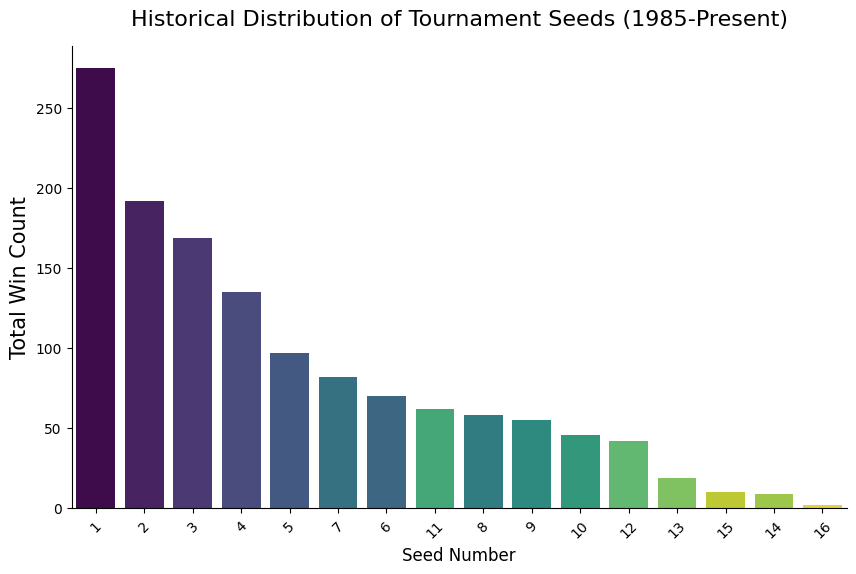

In [ ]:
seed_counts = df_filtered_rounds['w_seed_number'].value_counts().sort_index()

# Convert the Series to a DataFrame for easier plotting with seaborn
seed_counts_df = seed_counts.reset_index()
seed_counts_df.columns = ['w_seed_number', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=seed_counts_df, x='w_seed_number', y='count', hue='w_seed_number', palette='viridis', legend=False,
            order=seed_counts_df.sort_values('count', ascending=False)['w_seed_number'])

sns.despine()
plt.title('Historical Distribution of Tournament Seeds (1985-Present)', fontsize=16, pad=15)
plt.xlabel('Seed Number', fontsize=12)
plt.ylabel('Total Win Count', fontsize=15)
plt.xticks(rotation=45)
plt.show()

## Betting Outputs

In [ ]:
bet = 20

def multiplier(seed_diff):
    if seed_diff <= 1:
        return 0.8
    elif seed_diff <= 3:
        return 0.6
    elif seed_diff <= 5:
        return 0.5
    elif seed_diff <= 7:
        return 0.4
    else:
        return 0.2

df_filtered_rounds["favorite_seed"] = df_filtered_rounds[["w_seed_number","l_seed_number"]].min(axis=1)
df_filtered_rounds["underdog_seed"] = df_filtered_rounds[["w_seed_number","l_seed_number"]].max(axis=1)

df_filtered_rounds["seed_diff"] = df_filtered_rounds["underdog_seed"] - df_filtered_rounds["favorite_seed"]

df_filtered_rounds["favorite_won"] = df_filtered_rounds["w_seed_number"] == df_filtered_rounds["favorite_seed"]
df_filtered_rounds["multiplier"] = df_filtered_rounds["seed_diff"].apply(multiplier)

df_filtered_rounds["profit"] = np.where(
    df_filtered_rounds["favorite_won"] == True,
    bet * df_filtered_rounds["multiplier"],
    -bet
)

total_profit = df_filtered_rounds["profit"].sum()
roi = total_profit / (bet * len(df_filtered_rounds))

print(f"Your total Profit was: {total_profit} and your ROI was: {roi}")

Your total Profit was: 216.0 and your ROI was: 0.00816326530612245


In [ ]:
print((32+16+8+2+1)*20)

print(len(df_filtered_rounds)*20)

1180
26460


# 4. Make Predictions
